<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Attention Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
An LSTM squeezes a whole sequence into one final hidden state, and everything after that has to work from that single vector. Attention removes that bottleneck. Instead of one summary, the model looks back at every step and takes a weighted average, deciding for itself which steps matter.
</div>

## the bottleneck

in the RNN and LSTM notebooks the prediction came from `h` at the last step. a 30 word sentence and a 3 word sentence both end up as one vector of the same size.

that works for a small task like remembering one bit. for translation it does not, the whole meaning of a long sentence cannot fit in 128 numbers.

## the fix in one line

keep **all** the hidden states, and take a weighted average of them:

```
output = sum over t of  weight_t * h_t
```

where the weights add up to 1 and are computed from the data, not fixed. a step that matters gets a weight near 1, a step that does not gets near 0.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# five hidden states, pretend these came from an encoder
h = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.9, 0.1],
    [0.2, 0.9],
    [0.5, 0.5],
])

weights = np.array([0.05, 0.05, 0.8, 0.05, 0.05])   # picked by hand for now
context = weights @ h

print("weights sum to :", weights.sum())
print("context vector :", context)
print("almost equal to h[2] :", h[2])

weights sum to : 1.0
context vector : [0.805 0.2  ]
almost equal to h[2] : [0.9 0.1]


so with the weight mass on position 2 the output is basicaly h[2]. attention is soft selection, and because its a weighted sum instead of a hard pick, its differentiable and can be trained.

## where the weights come from

three names, and they are all just vectors:

- **query** : what am i looking for right now
- **key** : what does each position advertise about itself
- **value** : what each position actually gives back if selected

the score for a position is the dot product of the query with that position's key. high dot product means they point the same way, so that position is relevant. then softmax turns the scores into weights that sum to 1.

In [7]:
def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

# keys are made a bit long on purpose, otherwise the softmax comes out nearly flat
keys = 3 * np.array([
    [1.0, 0.0],     # position 0 advertises "animal"
    [0.0, 1.0],     # position 1 advertises "vehicle"
    [0.9, 0.2],
    [0.1, 1.0],
])
values = np.array([[10.0], [20.0], [11.0], [21.0]])

query = np.array([1.0, 0.0])        # i am looking for animal things

scores = keys @ query
weights = softmax(scores)
out = weights @ values

print("scores  :", np.round(scores, 2))
print("weights :", np.round(weights, 3))
print("output  :", np.round(out, 2))

scores  : [3.  0.  2.7 0.3]
weights : [0.538 0.027 0.399 0.036]
output  : [11.06]


the query pointed in the animal direction so positions 0 and 2 took about 94 percent of the weight between them, and the output landed at 11.07, right between their values 10 and 11. the vehicle positions were ignored.

In [3]:
query2 = np.array([0.0, 1.0])       # now looking for vehicle things
w2 = softmax(keys @ query2)
print("weights :", np.round(w2, 3))
print("output  :", np.round(w2 @ values, 2))

weights : [0.023 0.467 0.042 0.467]
output  : [19.85]


flip the query to the vehicle direction and the output jumps to 19.85, near values 20 and 21. same keys, same values, nothing retrained, only the query changed. the selection happens at runtime.

## why divide by sqrt(d)

dot products get bigger as the vectors get longer. big scores make softmax almost a hard max, one weight becomes 1 and the rest 0, and then the gradient dies. dividing by the square root of the dimension keeps the scores in a sane range.

In [4]:
rng = np.random.default_rng(0)

for d in [4, 64, 512]:
    q = rng.normal(0, 1, d)
    k = rng.normal(0, 1, (6, d))
    raw = k @ q
    scaled = raw / np.sqrt(d)
    print("d =", str(d).rjust(3),
          " raw scores range", round(raw.min(), 1), "to", round(raw.max(), 1),
          "  after scaling", round(scaled.min(), 2), "to", round(scaled.max(), 2))

d =   4  raw scores range -1.1 to 0.8   after scaling -0.57 to 0.41
d =  64  raw scores range -14.6 to 9.1   after scaling -1.82 to 1.14
d = 512  raw scores range -56.6 to 37.8   after scaling -2.5 to 1.67


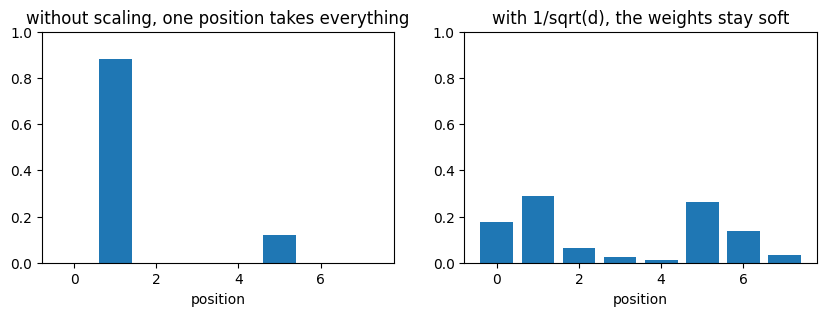

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10,3))
d = 512
q = rng.normal(0, 1, d)
k = rng.normal(0, 1, (8, d))

ax[0].bar(range(8), softmax(k @ q))
ax[0].set_title('without scaling, one position takes everything')
ax[1].bar(range(8), softmax((k @ q) / np.sqrt(d)))
ax[1].set_title('with 1/sqrt(d), the weights stay soft')
for a in ax:
    a.set_ylim(0,1); a.set_xlabel('position')
plt.show()

## self attention

in the example above the query came from outside. in **self** attention the query, key and value all come from the same sequence. so every position looks at every other position and asks who is relevant to me.

that is the whole idea behind the transformer, and it is written out properly in notebook 02.

## attention vs an rnn, the practical difference

| | rnn / lstm | attention |
|---|---|---|
| how far can it look | through the hidden state, decays | any position, directly |
| path length between two steps | t steps apart means t hops | always 1 hop |
| order of computation | strictly one step at a time | all positions at once |
| cost | O(T) | O(T^2), every pair scored |

that third row is why transformers took over. an RNN cannot start step 5 before step 4 finishes, attention computes all positions in parallel, wich fits gpus.

### recap
- attention is a weighted average of all positions, weights coming from a softmax over dot products
- query is what im looking for, key is what each position offers, value is what it returns
- scaling by sqrt(d) keeps the softmax from going hard
- the gain over an rnn is a direct path to every position, no decay in between